In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
entropy_all_file = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/calculated_barcode_entropy_wDNAdebrisflag_df.tsv'
entropy_all = pd.read_csv(entropy_all_file, sep=',', index_col=0)
entropy_all['atac_bc'] = entropy_all.index.str.split('-').str[0]
entropy_all.head(2)

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,atac_bc
CAGGTTACAGCCTAAA-1,0.005184,2.345061,28,1.782331,0.168245,0.999594,NO,CAGGTTACAGCCTAAA
GAACAATGTCGGTTAT-1,0.203897,0.735687,449,0.185787,0.830450,0.968089,NO,GAACAATGTCGGTTAT


In [3]:
entropy_all.shape

(33287, 8)

In [4]:
entropy_w_DNAdebrisflag_file = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/entropy_filtered_bc_w_DNAdebrisflag_df.tsv'
entropy_w_DNAdebrisflag_df = pd.read_csv(entropy_w_DNAdebrisflag_file, sep=',', index_col=0)
entropy_w_DNAdebrisflag_df['atac_bc'] = entropy_w_DNAdebrisflag_df.index.str.split('-').str[0]
entropy_w_DNAdebrisflag_df.head(2)

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,atac_bc
CGTGTTTCAAACCTAG-1,0.998157,1.989804,26417,1.111023,0.329222,0.525430,NO,CGTGTTTCAAACCTAG
TCCTCCATCAGGTTCC-1,0.985064,0.500669,4760,0.105701,0.899693,0.428163,YES,TCCTCCATCAGGTTCC


In [5]:
entropy_w_DNAdebrisflag_df.shape

(2125, 8)

In [6]:
final_bc_file = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/entropy_filtered_bc_df.tsv'
entropy_df = pd.read_csv(final_bc_file, sep=',', index_col=0)
entropy_df['atac_bc'] = entropy_df.index.str.split('-').str[0]
entropy_df.head(2)

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,atac_bc
CGTGTTTCAAACCTAG-1,0.998157,1.989804,26417,1.111023,0.329222,0.525430,NO,CGTGTTTCAAACCTAG
GGAGGCTTCATGGATA-1,0.969950,0.401102,2468,0.077603,0.925332,0.601704,NO,GGAGGCTTCATGGATA


In [7]:
entropy_df.shape

(2101, 8)

# Prepare for illustratrion figure

In [8]:
# Preparation of scatter plot data
frag_file = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/fragments.tsv'
frag_df = pd.read_csv(frag_file, sep='\t', header=None, names=['chr', 'start', 'end', 'atac_barcodes', 'support'])
frag_df['atac_bc'] = frag_df['atac_barcodes'].str.split('-').str[0]

total_fragments = frag_df.groupby('atac_barcodes').size().reset_index(name='total_fragments')
total_fragments.set_index('atac_barcodes', inplace=True)

In [9]:
_entropy_all = entropy_all.merge(total_fragments, left_index=True, right_index=True, how='left')
_entropy_w_DNAdebrisflag_df = entropy_w_DNAdebrisflag_df.merge(total_fragments, left_index=True, right_index=True, how='left')
_entropy_df = entropy_df.merge(total_fragments, left_index=True, right_index=True, how='left')
_entropy_all.head(2)

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,atac_bc,total_fragments
CAGGTTACAGCCTAAA-1,0.005184,2.345061,28,1.782331,0.168245,0.999594,NO,CAGGTTACAGCCTAAA,537
GAACAATGTCGGTTAT-1,0.203897,0.735687,449,0.185787,0.830450,0.968089,NO,GAACAATGTCGGTTAT,4841


# Figure

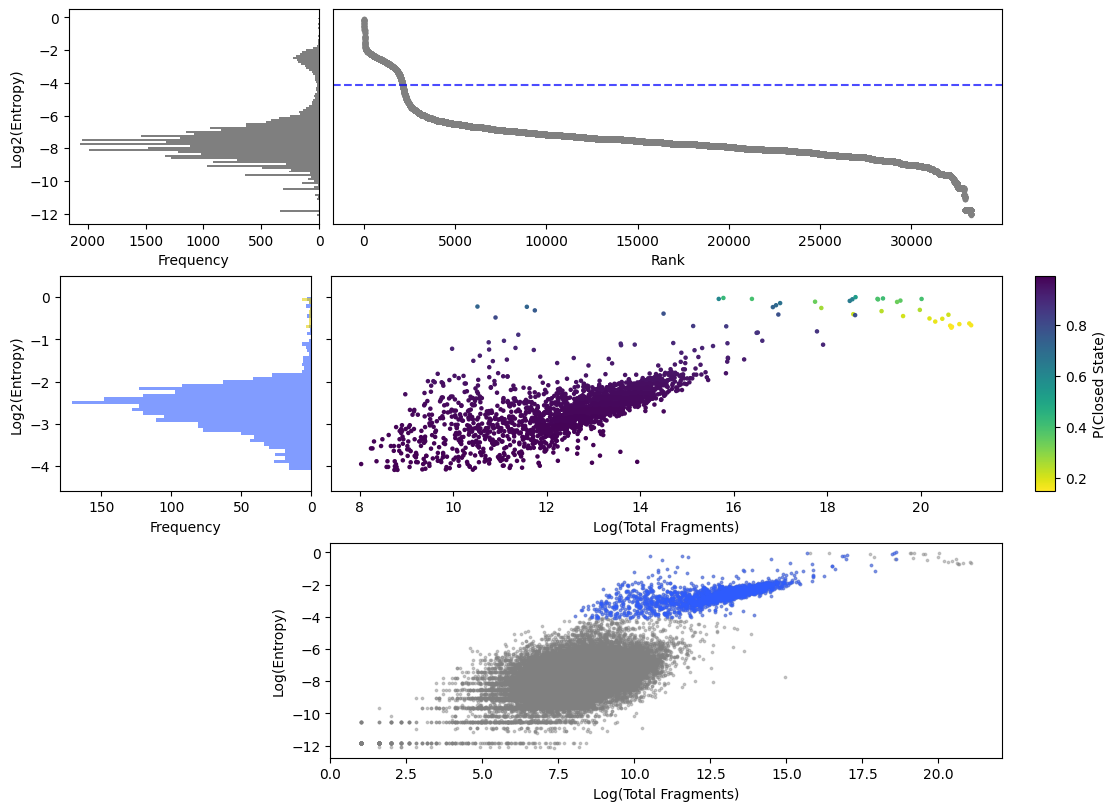

In [10]:
fig = plt.figure(layout="constrained", figsize=(10, 8))

# Create a top-level GridSpec with 3 rows
gs = fig.add_gridspec(3, 1, height_ratios=[1, 1, 1])

# --- Row 1 ---
gs0 = gs[0].subgridspec(1, 2, width_ratios=[3, 8])
ax1 = fig.add_subplot(gs0[0, 0])
ax2 = fig.add_subplot(gs0[0, 1])

# --- Row 2 ---
gs1 = gs[1].subgridspec(1, 2, width_ratios=[3, 8])
ax3 = fig.add_subplot(gs1[0, 0])
ax4 = fig.add_subplot(gs1[0, 1])

# --- Row 3 ---
# ax5 = fig.add_subplot(gs[2, 0])
gs2 = gs[2].subgridspec(1, 2, width_ratios=[3, 8])
ax5 = fig.add_subplot(gs2[0, 0])
ax6 = fig.add_subplot(gs2[0, 1])

# # Labeling for clarity
# ax1.set_title("1")
# ax2.set_title("10")
# ax3.set_title("3")
# ax4.set_title("4")
# ax5.set_title("5")
# ax6.set_title("6")

entropy_min, entropy_max = _entropy_all['Entropy'].min(), _entropy_all['Entropy'].max()

# ax1
s1 = ax1.hist(np.log2(_entropy_all['Entropy']), bins=100, alpha=0.5, color='black', 
              orientation='horizontal')
ax1.set_ylim(np.log2(entropy_min) - 0.5, np.log2(entropy_max) + 0.5)
ax1.invert_xaxis()
# ax1.yaxis.tick_right()
ax1.set_xlabel('Frequency')
ax1.set_ylabel('Log2(Entropy)')
# ax2 
sorted_log2entropy_list = np.log2(_entropy_all['Entropy'].dropna().sort_values(ascending=False).values)
rank_list = np.arange( len(sorted_log2entropy_list) )
entropy_cutoff = np.log2(entropy_df['Entropy'].min())
s2 = ax2.plot(rank_list, sorted_log2entropy_list,  'o', markersize=3, color='grey')
ax2.axhline(entropy_cutoff, color='blue', linestyle='--', alpha=0.7)
ax2.set_xlabel('Rank')
# set ax2 x-ticks to be none
ax2.set_yticks([])
# ax2.set_ylabel('Log2(Entropy)')
# ax3 
DNAdebris_index = entropy_w_DNAdebrisflag_df['DNA_debris'] == 'YES'
noDNAdebris_index = entropy_w_DNAdebrisflag_df['DNA_debris'] == 'NO'
s3 = ax3.hist(np.log2(entropy_w_DNAdebrisflag_df['Entropy'][noDNAdebris_index]), bins=50, alpha=0.6, color="#2E5BFF",
              orientation='horizontal')
s3_a = ax3.hist(np.log2(entropy_w_DNAdebrisflag_df['Entropy'][DNAdebris_index]),  alpha=0.6, color="#E4D00A",
              orientation='horizontal')
ax3.set_ylim(entropy_cutoff - 0.5, np.log2(entropy_max) + 0.5)
ax3.invert_xaxis()
ax3.set_ylabel('Log2(Entropy)')
ax3.set_xlabel('Frequency')

# ax4 
s4 = ax4.scatter(np.log2(_entropy_w_DNAdebrisflag_df['total_fragments']), np.log2(_entropy_w_DNAdebrisflag_df['Entropy']),
                 c = _entropy_w_DNAdebrisflag_df['P_closed_state'],
                 alpha=1, s=5, cmap='viridis_r' )
ax4.set_xlabel('Log(Total Fragments)')
ax4.set_yticklabels([]) # hide y-ticks
ax4.set_ylim(entropy_cutoff - 0.5, np.log2(entropy_max) + 0.5)


from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# Create colorbar axes OUTSIDE ax2 [x_offset, y_offset, width, height]
cax2 = inset_axes(ax4,
                   width="3%",  
                   height="100%",
                   loc='lower left',
                   bbox_to_anchor=(1.05, 0., 1, 1), # (x, y, width, height) relative to ax2
                   bbox_transform=ax4.transAxes,
                   borderpad=0)
fig.colorbar(s4, cax=cax2, label='P(Closed State)')
# ax5 
# # not show suplot for ax5
# ax5.set_ylabel('Log2(Entropy)', color='none') 
# ax5.tick_params(axis='both', which='both', colors='none')
# for spine in ax5.spines.values():
#     spine.set_visible(False)
ax5.axis(False)
# ax6
s6 = ax6.scatter(np.log2(_entropy_all['total_fragments']), np.log2(_entropy_all['Entropy']), 
                 c ='grey', alpha=0.4, s=3)
ax6.set_xlabel('Log(Total Fragments)')
ax6.set_ylabel('Log(Entropy)')
ax6.scatter(np.log2(_entropy_df['total_fragments']), np.log2(_entropy_df['Entropy']), 
                 c ='#2E5BFF', alpha=0.4, s=3)



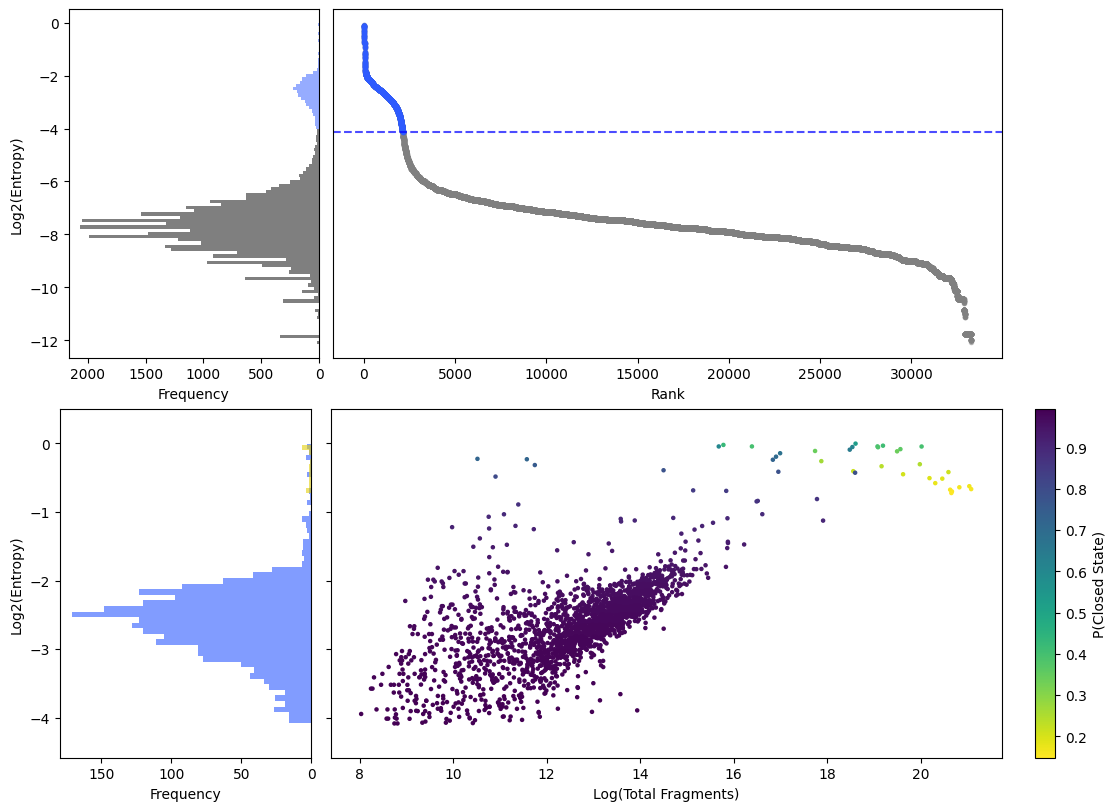

In [11]:
fig = plt.figure(layout="constrained", figsize=(10, 8))

# Create a top-level GridSpec with 3 rows
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1])

# --- Row 1 ---
gs0 = gs[0].subgridspec(1, 2, width_ratios=[3, 8])
ax1 = fig.add_subplot(gs0[0, 0])
ax2 = fig.add_subplot(gs0[0, 1])

# --- Row 2 ---
gs1 = gs[1].subgridspec(1, 2, width_ratios=[3, 8])
ax3 = fig.add_subplot(gs1[0, 0])
ax4 = fig.add_subplot(gs1[0, 1])


entropy_min, entropy_max = _entropy_all['Entropy'].min(), _entropy_all['Entropy'].max()

# ax1
n, bins, patches = ax1.hist(np.log2(_entropy_all['Entropy']), bins=100, alpha=0.5, color='black', 
              orientation='horizontal')
for patch in patches:
    if patch.get_y() >= entropy_cutoff:
        patch.set_facecolor('#2E5BFF')
        patch.set_alpha(0.5) 
ax1.set_ylim(np.log2(entropy_min) - 0.5, np.log2(entropy_max) + 0.5)
ax1.invert_xaxis()
ax1.set_xlabel('Frequency')
ax1.set_ylabel('Log2(Entropy)')
# ax2 
sorted_log2entropy_list = np.log2(_entropy_all['Entropy'].dropna().sort_values(ascending=False).values)
rank_list = np.arange( len(sorted_log2entropy_list) )
entropy_cutoff = np.log2(entropy_df['Entropy'].min())
above_cutoff_index = sorted_log2entropy_list >= entropy_cutoff
s2 = ax2.plot(rank_list, sorted_log2entropy_list,  'o', markersize=3, color='grey', alpha=0.5)
s2 = ax2.plot(rank_list[above_cutoff_index], sorted_log2entropy_list[above_cutoff_index],  'o', markersize=3, color='#2E5BFF', alpha=0.5)
ax2.axhline(entropy_cutoff, color='blue', linestyle='--', alpha=0.7)
ax2.set_xlabel('Rank')
# set ax2 x-ticks to be none
ax2.set_yticks([])

# ax3 
DNAdebris_index = entropy_w_DNAdebrisflag_df['DNA_debris'] == 'YES'
noDNAdebris_index = entropy_w_DNAdebrisflag_df['DNA_debris'] == 'NO'
s3 = ax3.hist(np.log2(entropy_w_DNAdebrisflag_df['Entropy'][noDNAdebris_index]), bins=50, alpha=0.6, color="#2E5BFF",
              orientation='horizontal')
s3_a = ax3.hist(np.log2(entropy_w_DNAdebrisflag_df['Entropy'][DNAdebris_index]),  alpha=0.6, color="#E4D00A",
              orientation='horizontal')
ax3.set_ylim(entropy_cutoff - 0.5, np.log2(entropy_max) + 0.5)
ax3.invert_xaxis()
ax3.set_ylabel('Log2(Entropy)')
ax3.set_xlabel('Frequency')

# ax4 
s4 = ax4.scatter(np.log2(_entropy_w_DNAdebrisflag_df['total_fragments']), np.log2(_entropy_w_DNAdebrisflag_df['Entropy']),
                 c = _entropy_w_DNAdebrisflag_df['P_closed_state'],
                 alpha=1, s=5, cmap='viridis_r' )
ax4.set_xlabel('Log(Total Fragments)')
ax4.set_yticklabels([]) # hide y-ticks
ax4.set_ylim(entropy_cutoff - 0.5, np.log2(entropy_max) + 0.5)


from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# Create colorbar axes OUTSIDE ax2 [x_offset, y_offset, width, height]
cax2 = inset_axes(ax4,
                   width="3%",  
                   height="100%",
                   loc='lower left',
                   bbox_to_anchor=(1.05, 0., 1, 1), # (x, y, width, height) relative to ax2
                   bbox_transform=ax4.transAxes,
                   borderpad=0)
fig.colorbar(s4, cax=cax2, label='P(Closed State)')




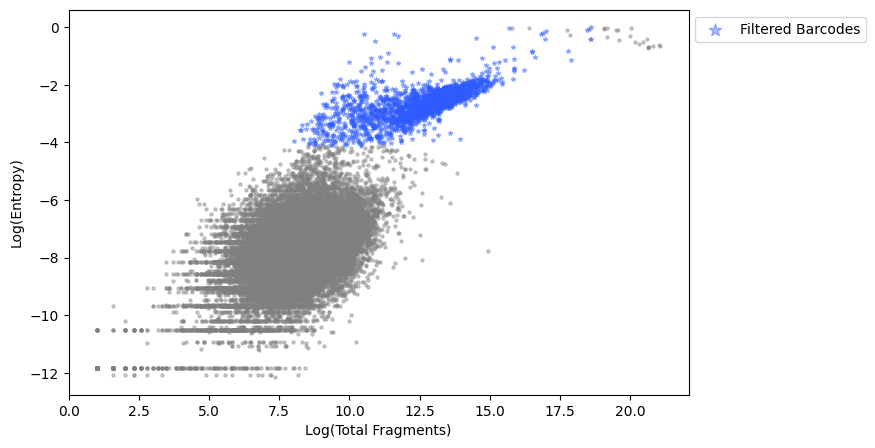

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
filtered_out_index = ~_entropy_all.index.isin(_entropy_df.index)
filtered_in_index = _entropy_all.index.isin(_entropy_df.index)
s = ax.scatter(np.log2(_entropy_all['total_fragments'][filtered_out_index]), np.log2(_entropy_all['Entropy'][filtered_out_index]), 
                 c ='grey', alpha=0.4, s=5)
ax.set_xlabel('Log(Total Fragments)')
ax.set_ylabel('Log(Entropy)')
ax.scatter(np.log2(_entropy_df['total_fragments']), np.log2(_entropy_df['Entropy']), 
                 c ='#2E5BFF', alpha=0.4, s=10, marker='*',
                 label='Filtered Barcodes', )
# ax.legend(['All Barcodes', 'Filtered Barcodes'], loc='upper left', bbox_to_anchor=(1, 1), markerscale=3.0)
ax.legend(bbox_to_anchor=(1, 1), markerscale=3.0)

## Demonstration of the workflow of SADE

In [79]:
entropy_min, entropy_max = entropy_all['Entropy'].min(), entropy_all['Entropy'].max()


## Step1. Entropy under mixture distribution is calculated for each barcode 
(in entropy_all_file i.e., calculated_barcode_entropy_wDNAdebrisflag_df.tsv file) 

(0.0, 1.0)

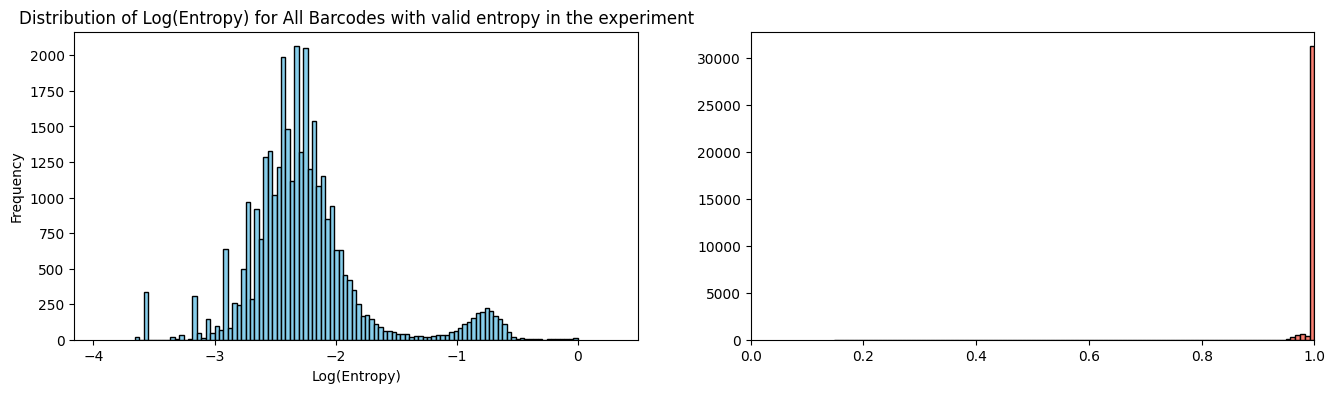

In [111]:
fig, ax = plt.subplots(ncols=2, figsize=(16, 4))
_ = ax[0].hist(np.log10(entropy_all['Entropy']), bins=100, color='skyblue', edgecolor='black')
ax[0].set_xlabel('Log(Entropy)')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Distribution of Log(Entropy) for All Barcodes with valid entropy in the experiment')
ax[0].set_xlim(np.log10(entropy_min) - 0.5, np.log10(entropy_max) + 0.5)

_ = ax[1].hist(entropy_all['P_closed_state'], bins=100, color='salmon', edgecolor='black')
ax[1].set_xlim(0, 1)

## Step 2. Smooth curved fitted to filter out empty barcodes/droplets
(in entropy_filtered_bc_w_DNAdebrisflag_df.tsv file)

(0.0, 1.0)

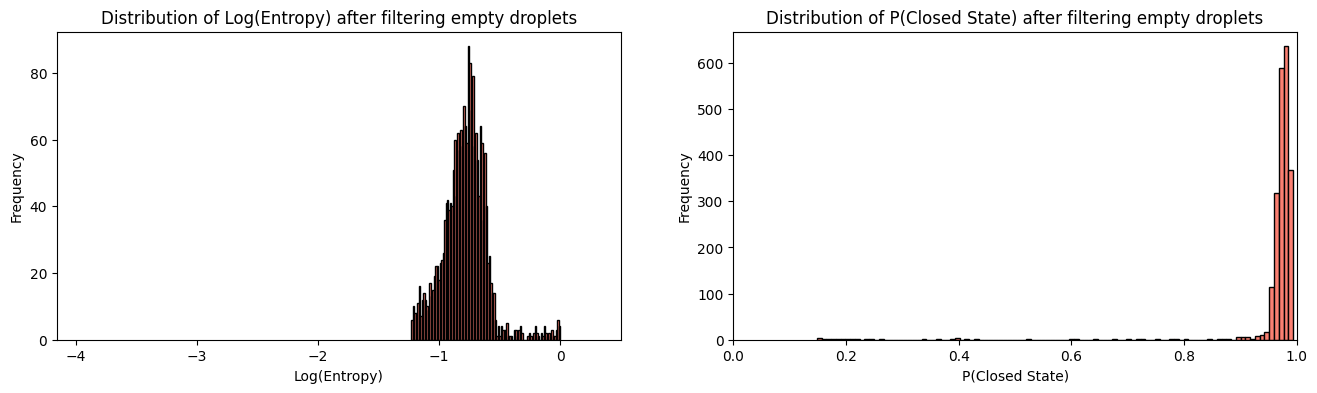

In [114]:
fig, ax = plt.subplots(ncols=2, figsize=(16, 4))
_ = ax[0].hist(np.log10(entropy_w_DNAdebrisflag_df['Entropy']), bins=100, color='salmon', edgecolor='black')
ax[0].set_xlabel('Log(Entropy)')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Distribution of Log(Entropy) after filtering empty droplets')
ax[0].set_xlim(np.log10(entropy_min) - 0.5, np.log10(entropy_max) + 0.5)


_ = ax[1].hist(entropy_w_DNAdebrisflag_df['P_closed_state'], bins=100, color='salmon', edgecolor='black')
ax[1].set_xlabel('P(Closed State)')
ax[1].set_ylabel('Frequency')
ax[1].set_title('Distribution of P(Closed State) after filtering empty droplets')
ax[1].set_xlim(0, 1)

## Step3. Filter out DNA-debris using P-closed-state estimated in the mixture distribution at threshold 0.5

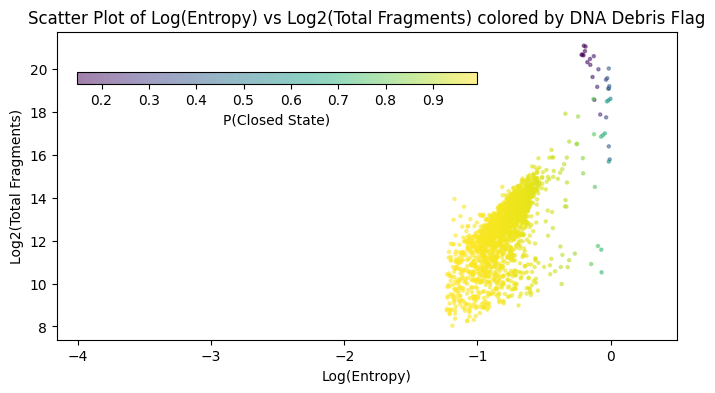

In [136]:
fig, ax = plt.subplots(figsize=(8, 4))
s1 = ax.scatter(np.log10(_entropy_w_DNAdebrisflag_df['Entropy']), np.log2(_entropy_w_DNAdebrisflag_df['total_fragments']), 
                c = _entropy_w_DNAdebrisflag_df['P_closed_state'],
                alpha=0.5, s=5,  label='No DNA Debris')

ax.set_xlabel('Log(Entropy)')
ax.set_ylabel('Log2(Total Fragments)')
ax.set_title('Scatter Plot of Log(Entropy) vs Log2(Total Fragments) colored by DNA Debris Flag')
ax.set_xlim(np.log10(entropy_min) - 0.5, np.log10(entropy_max) + 0.5)

# [x0, y0, width, height]
cax = fig.add_axes([0.15, 0.75, 0.5, 0.03]) 
cbar = fig.colorbar(s1, cax=cax, orientation='horizontal', label='P(Closed State)')

(-4.157647056997911, 0.49919893229403006)

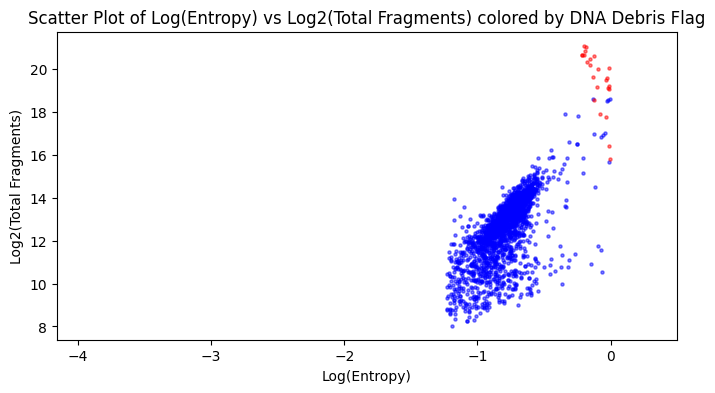

In [123]:
fig, ax = plt.subplots(figsize=(8, 4))
DNA_debris_index = _entropy_w_DNAdebrisflag_df['DNA_debris'] == 'YES'
noDNA_debris_index = _entropy_w_DNAdebrisflag_df['DNA_debris'] == 'NO'
s1 = ax.scatter(np.log10(_entropy_w_DNAdebrisflag_df['Entropy'][noDNA_debris_index]), np.log2(_entropy_w_DNAdebrisflag_df['total_fragments'][noDNA_debris_index]), 
                alpha=0.5, s=5, color='blue', label='No DNA Debris')
s2 = ax.scatter(np.log10(_entropy_w_DNAdebrisflag_df['Entropy'][DNA_debris_index]), np.log2(_entropy_w_DNAdebrisflag_df['total_fragments'][DNA_debris_index]), 
                 alpha=0.5, s=5, color='red', label='DNA Debris')

ax.set_xlabel('Log(Entropy)')
ax.set_ylabel('Log2(Total Fragments)')
ax.set_title('Scatter Plot of Log(Entropy) vs Log2(Total Fragments) colored by DNA Debris Flag')
ax.set_xlim(np.log10(entropy_min) - 0.5, np.log10(entropy_max) + 0.5)


(-4.157647056997911, 0.49919893229403006)

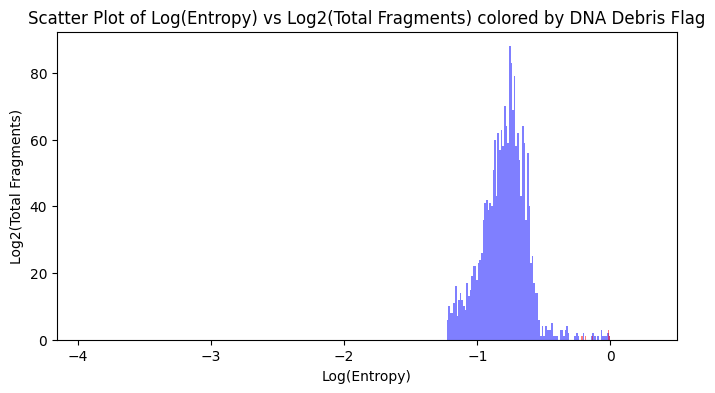

In [139]:
fig, ax = plt.subplots(figsize=(8, 4))
DNA_debris_index = _entropy_w_DNAdebrisflag_df['DNA_debris'] == 'YES'
noDNA_debris_index = _entropy_w_DNAdebrisflag_df['DNA_debris'] == 'NO'
s1 = ax.hist(np.log10(_entropy_w_DNAdebrisflag_df['Entropy'][noDNA_debris_index]), bins=100,
                alpha=0.5,color='blue', label='No DNA Debris')
s2 = ax.hist(np.log10(_entropy_w_DNAdebrisflag_df['Entropy'][DNA_debris_index]), bins=100,
                alpha=0.5,color='red', label='DNA Debris')

ax.set_xlabel('Log(Entropy)')
ax.set_ylabel('Log2(Total Fragments)')
ax.set_title('Scatter Plot of Log(Entropy) vs Log2(Total Fragments) colored by DNA Debris Flag')
ax.set_xlim(np.log10(entropy_min) - 0.5, np.log10(entropy_max) + 0.5)


Text(0.5, 1.0, 'Scatter Plot of Log(Total Fragments) vs P(Closed State) colored by DNA Debris Flag')

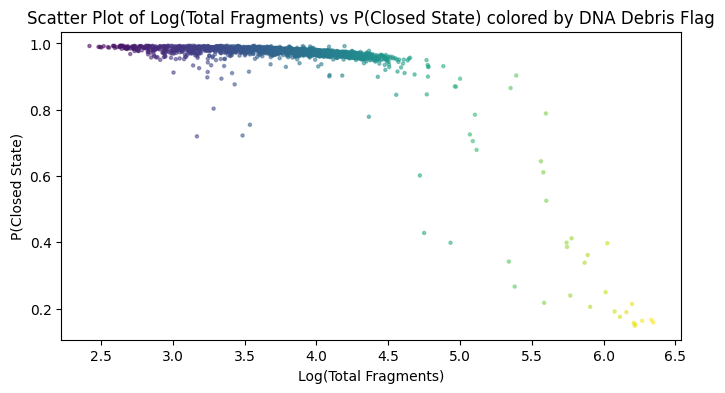

In [127]:
fig, ax = plt.subplots(figsize=(8, 4))
scatter2 = ax.scatter(np.log10(_entropy_w_DNAdebrisflag_df['total_fragments']), _entropy_w_DNAdebrisflag_df['P_closed_state'], 
               c = np.log2(_entropy_w_DNAdebrisflag_df['total_fragments']),  alpha=0.5, s=5)


ax.set_xlabel('Log(Total Fragments)')
ax.set_ylabel('P(Closed State)')
ax.set_title('Scatter Plot of Log(Total Fragments) vs P(Closed State) colored by DNA Debris Flag')
# ax.set_xlim(np.log10(entropy_min) - 0.5, np.log10(entropy_max) + 0.5)


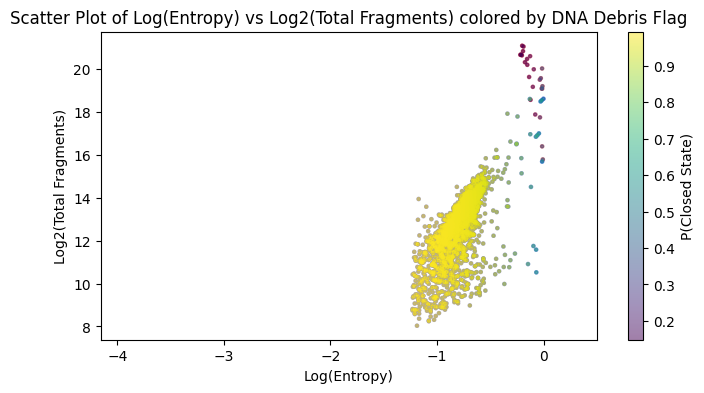

In [107]:
fig, ax = plt.subplots(figsize=(8, 4))
scatter2 = ax.scatter(np.log10(_entropy_w_DNAdebrisflag_df['Entropy']), np.log2(_entropy_w_DNAdebrisflag_df['total_fragments']), 
               c = _entropy_w_DNAdebrisflag_df['P_closed_state'],  alpha=0.5, s=5)
_ = ax.scatter(np.log10(_entropy_w_DNAdebrisflag_df['Entropy']), np.log2(_entropy_w_DNAdebrisflag_df['total_fragments']), 
               c = _entropy_w_DNAdebrisflag_df['DNA_debris'].map({'YES': 'red', 'NO': 'blue'}),  alpha=0.5, s=5)

ax.set_xlabel('Log(Entropy)')
ax.set_ylabel('Log2(Total Fragments)')
ax.set_title('Scatter Plot of Log(Entropy) vs Log2(Total Fragments) colored by DNA Debris Flag')
ax.set_xlim(np.log10(entropy_min) - 0.5, np.log10(entropy_max) + 0.5)

fig.colorbar(scatter2, label='P(Closed State)')

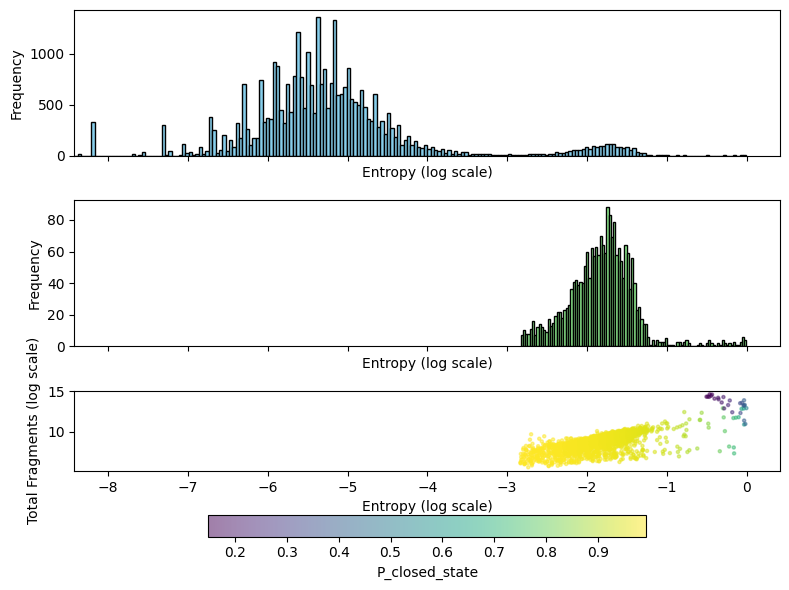

In [143]:
fig, ax = plt.subplots(figsize=(8, 6), nrows=3, ncols=1, sharex=True)
xlims = min(np.log(entropy_all['Entropy'].min()), np.log(entropy_df['Entropy'].min()))

_ = ax[0].hist(np.log(entropy_all['Entropy']), bins=200, color='skyblue', edgecolor='black')
_ = ax[1].hist(np.log(entropy_df['Entropy']), bins=100, color='lightgreen', edgecolor='black')


ax[0].set_xlabel('Entropy (log scale)')
ax[0].set_ylabel('Frequency')

ax[1].set_xlabel('Entropy (log scale)')
ax[1].set_ylabel('Frequency')

ax[2].scatter(np.log(a['Entropy']),
              np.log(a['total_fragments']),
                alpha=0.5, s= 5,
                c=a['P_closed_state'])
ax[2].set_xlabel('Entropy (log scale)')
ax[2].set_ylabel('Total Fragments (log scale)')
ax[2].set_xlim(xlims)
cbar = plt.colorbar(ax[2].collections[0], ax=ax[2],orientation="horizontal", pad=0.3,)
cbar.set_label('P_closed_state')
plt.tight_layout()


Text(0, 0.5, 'Frequency')

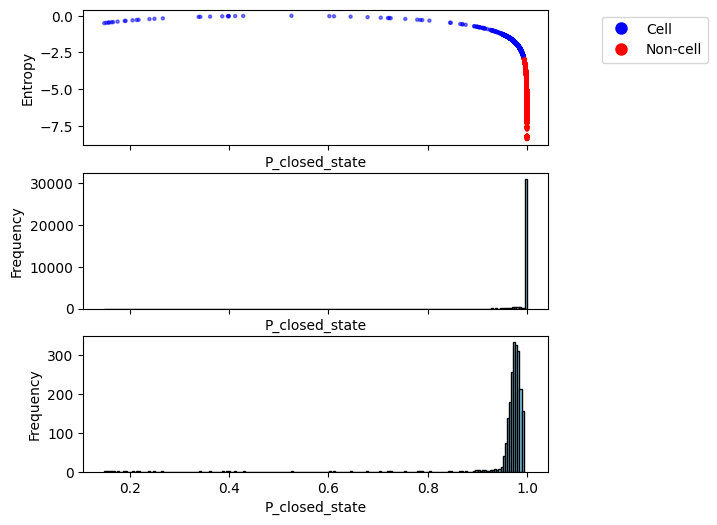

In [ ]:
fig, ax = plt.subplots(nrows=3, figsize=(6, 6), sharex=True)
entropy_all['cell'] = entropy_all['Entropy'] >= entropy_df['Entropy'].min()
ax[0].scatter(entropy_all['P_closed_state'], np.log(entropy_all['Entropy']),  alpha=0.5,
           c=entropy_all['cell'].map({True: 'blue', False: 'red'}), 
           s = 5)
ax[0].set_ylabel('Entropy')
ax[0].set_xlabel('P_closed_state')
ax[0].legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label='Cell', markerfacecolor='blue', markersize=10),
                   plt.Line2D([0], [0], marker='o', color='w', label='Non-cell', markerfacecolor='red', markersize=10)], 
          bbox_to_anchor=(1.1, 1), loc='upper left')

_ = ax[1].hist(entropy_all['P_closed_state'], bins=200, color='skyblue', edgecolor='black')
ax[1].set_xlabel('P_closed_state')
ax[1].set_ylabel('Frequency')

_ = ax[2].hist(entropy_df['P_closed_state'], bins=200, color='skyblue', edgecolor='black')
ax[2].set_xlabel('P_closed_state')
ax[2].set_ylabel('Frequency')